# Multifactor Models Lab 02: FF3 Benchmark-Relative Attribution

- Objective: explain benchmark-relative performance with one `FF3` model.
- Benchmark: `SPY`; active portfolio: `45% SPY`, `35% VTV`, `20% IWM`.
- Flow: build data, describe active results, run `FF3` attribution, extend the same model to active risk.


## Core Definitions

- Active return: $AR_t = R_{P,t} - R_{B,t}$.
- `FF3` active regression:
  $$
  AR_t = \alpha_A + b_{A,M}\,\mathrm{RMRF}_t + b_{A,S}\,\mathrm{SMB}_t + b_{A,H}\,\mathrm{HML}_t + u_t.
  $$
- Tracking error: $\sigma(AR_t)$.


In [ ]:
# If you are running this notebook in a fresh environment, this cell will
# install the only packages that are not always available by default.

import importlib
import subprocess
import sys

# Install only the packages that are missing.
for package in ["yfinance", "statsmodels", "matplotlib"]:
    try:
        importlib.import_module(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Modules used to download and parse the factor files.
import io
import re
import zipfile
import urllib.request

# Core libraries for data handling, plotting, and regressions.
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf

from IPython.display import display

# Set plotting style and numeric display format.
plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format


## Data Setup

- Data sources: Yahoo Finance (`yfinance`) and Kenneth French monthly factors.
- Frozen sample: `START = 2010-01-01`, `END = 2026-02-28`.
- Usable monthly return data starts in February 2010 because returns use `pct_change()`.


In [ ]:
# Freeze the sample window and define the benchmark used for active return.
START = pd.Timestamp("2010-01-01")
END = pd.Timestamp("2026-02-28")
BENCHMARK = "SPY"

# Active portfolio weights by ticker.
ACTIVE_WEIGHTS = {
    "SPY": 0.45,
    "VTV": 0.35,
    "IWM": 0.20,
}

# Plain-English role for each ETF in the portfolio.
ETF_ROLES = {
    "SPY": "Core market exposure",
    "VTV": "Value tilt",
    "IWM": "Small-cap tilt",
}

ALL_TICKERS = list(ACTIVE_WEIGHTS.keys())
FF3_FACTORS = ["RMRF", "SMB", "HML"]
ETF_DOWNLOAD_END = (END + pd.offsets.Day(1)).strftime("%Y-%m-%d")


def read_ken_french_monthly_zip(dataset_name):
    """Download a Ken French monthly factor file and return a monthly DataFrame in decimal form."""
    url = f"https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/{dataset_name}_CSV.zip"
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})

    # Download the zip file into memory.
    with urllib.request.urlopen(request) as response:
        raw = response.read()

    # Open the zip file in memory and extract the CSV text inside it.
    with zipfile.ZipFile(io.BytesIO(raw)) as zf:
        csv_name = zf.namelist()[0]
        text = zf.read(csv_name).decode("latin1")

    lines = text.splitlines()
    start_row = next(i for i, line in enumerate(lines) if re.match(r"^\d{6},", line))
    header = lines[start_row - 1]

    # Keep only the monthly data block and stop before footnotes/annual data.
    data_rows = []
    for line in lines[start_row:]:
        if not line.strip():
            break
        if not re.match(r"^\d{6},", line):
            break
        data_rows.append(line)

    df = pd.read_csv(io.StringIO("\n".join([header] + data_rows)))
    first_col = df.columns[0]
    df = df.rename(columns={first_col: "Date"})

    # Convert YYYYMM codes into month-end timestamps for time-series alignment.
    df["Date"] = pd.to_datetime(df["Date"].astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
    df = df.set_index("Date")

    # Rename factor labels to the notation used elsewhere in the course.
    renamed = {}
    for col in df.columns:
        clean = col.strip()
        if clean == "Mkt-RF":
            clean = "RMRF"
        renamed[col] = clean
    df = df.rename(columns=renamed)

    return df.apply(pd.to_numeric, errors="coerce") / 100


# Download FF3 monthly factors.
factors = read_ken_french_monthly_zip("F-F_Research_Data_Factors")
factors = factors.loc[(factors.index >= START) & (factors.index <= END), [*FF3_FACTORS, "RF"]].copy()

# yfinance treats the end date as exclusive, so add one day to keep
# February 2026 in the frozen sample while excluding later months.
raw_prices = yf.download(
    tickers=ALL_TICKERS,
    start=START.strftime("%Y-%m-%d"),
    end=ETF_DOWNLOAD_END,
    interval="1d",
    auto_adjust=False,
    progress=False,
)

# Multiple tickers usually create MultiIndex columns, so select the price field carefully.
if isinstance(raw_prices.columns, pd.MultiIndex):
    price_field = "Adj Close" if "Adj Close" in raw_prices.columns.get_level_values(0) else "Close"
    prices = raw_prices[price_field].copy()
else:
    price_field = "Adj Close" if "Adj Close" in raw_prices.columns else "Close"
    prices = raw_prices[[price_field]].copy()

# Keep columns in the same order as the weight dictionary.
prices = prices[ALL_TICKERS]

# Convert daily prices to month-end prices, then compute monthly returns.
monthly_prices = prices.resample("ME").last()
etf_returns = monthly_prices.pct_change().dropna()

# Compute active portfolio return from the ETF weights.
portfolio_return = sum(weight * etf_returns[ticker] for ticker, weight in ACTIVE_WEIGHTS.items())
portfolio_return = portfolio_return.rename("Portfolio")
benchmark_return = etf_returns[BENCHMARK].rename("Benchmark")
active_return = (portfolio_return - benchmark_return).rename("Active")

# Combine returns and factors on common dates only.
data = pd.concat([portfolio_return, benchmark_return, active_return], axis=1)
data = data.join(factors, how="inner").dropna().copy()
data = data.loc[(data.index >= START) & (data.index <= END)].copy()

# Excess returns subtract the same risk-free rate from portfolio and benchmark.
data["portfolio_excess"] = data["Portfolio"] - data["RF"]
data["benchmark_excess"] = data["Benchmark"] - data["RF"]

# Show the portfolio construction used in the lab.
weights_table = pd.DataFrame(
    {
        "Weight": pd.Series(ACTIVE_WEIGHTS),
        "Role in this lab": pd.Series(ETF_ROLES),
    }
)
weights_table["Weight"] = weights_table["Weight"].map(lambda x: f"{x:.0%}")

display(weights_table)
display(data[["Portfolio", "Benchmark", "Active", "RMRF", "SMB", "HML", "RF"]].head())

# Print checks so students can verify the frozen sample actually used.
print(f"Sample start: {data.index.min().date()}")
print(f"Sample end:   {data.index.max().date()}")
print(f"Months used:  {len(data)}")


,Weight,Role in this lab
SPY,45%,Core market exposure
VTV,35%,Value tilt
IWM,20%,Small-cap tilt


,Portfolio,Benchmark,Active,RMRF,SMB,HML,RF
Date,,,,,,,
2010-02-28,0.0322,0.0312,0.0010,0.0339,0.0118,0.0318,0.0000
2010-03-31,0.0654,0.0609,0.0045,0.0630,0.0146,0.0219,0.0001
2010-04-30,0.0246,0.0155,0.0091,0.0199,0.0484,0.0296,0.0001
2010-05-31,-0.0780,-0.0795,0.0014,-0.0790,0.0013,-0.0248,0.0001
2010-06-30,-0.0569,-0.0517,-0.0051,-0.0556,-0.0179,-0.0473,0.0001


Sample start: 2010-02-28
Sample end:   2026-02-28
Months used:  193


### How To Read The Setup Output

- Weights table confirms intended benchmark-relative tilts.
- Data preview confirms alignment of `Portfolio`, `Benchmark`, `Active`, `RMRF`, `SMB`, `HML`, and `RF`.
- Sample start/end and month count confirm the frozen sample used below.


## Descriptive Benchmark-Relative Output

- First ask what happened before asking why.
- Focus on average active return, tracking error, and cumulative relative wealth.


In [ ]:
# Convert returns into wealth indices so we can compare cumulative performance.
wealth = (1 + data[["Portfolio", "Benchmark"]]).cumprod()
relative_wealth = (wealth["Portfolio"] / wealth["Benchmark"]).rename("Relative wealth ratio")

# Build a compact descriptive summary for the portfolio, benchmark, and active return.
summary = pd.DataFrame(
    {
        "Average monthly return (%)": [
            data["Portfolio"].mean() * 100,
            data["Benchmark"].mean() * 100,
            data["Active"].mean() * 100,
        ],
        "Std. dev. (% per month)": [
            data["Portfolio"].std() * 100,
            data["Benchmark"].std() * 100,
            data["Active"].std() * 100,
        ],
    },
    index=["Active portfolio", "Benchmark (SPY)", "Active return"],
).round(3)

display(summary)

# Print a few headline numbers that are easy to refer to in the write-up.
print(f"Final wealth from $1 in the active portfolio: {wealth['Portfolio'].iloc[-1]:.3f}")
print(f"Final wealth from $1 in the benchmark:       {wealth['Benchmark'].iloc[-1]:.3f}")
print(f"Final benchmark-relative wealth ratio:       {relative_wealth.iloc[-1]:.3f}")
print(f"Tracking error (monthly std. dev. of active return): {data['Active'].std() * 100:.2f}%")


,Average monthly return (%),Std. dev. (% per month)
Active portfolio,1.1220,4.2390
Benchmark (SPY),1.2000,4.1160
Active return,-0.0780,0.8760


Final wealth from $1 in the active portfolio: 7.257
Final wealth from $1 in the benchmark:       8.514
Final benchmark-relative wealth ratio:       0.852
Tracking error (monthly std. dev. of active return): 0.88%


### How To Read The Summary

- `Portfolio mean - Benchmark mean` equals average active return.
- `Std. dev. of Active` is monthly tracking error.
- Relative wealth ratio above `1` means cumulative outperformance; below `1` means underperformance.


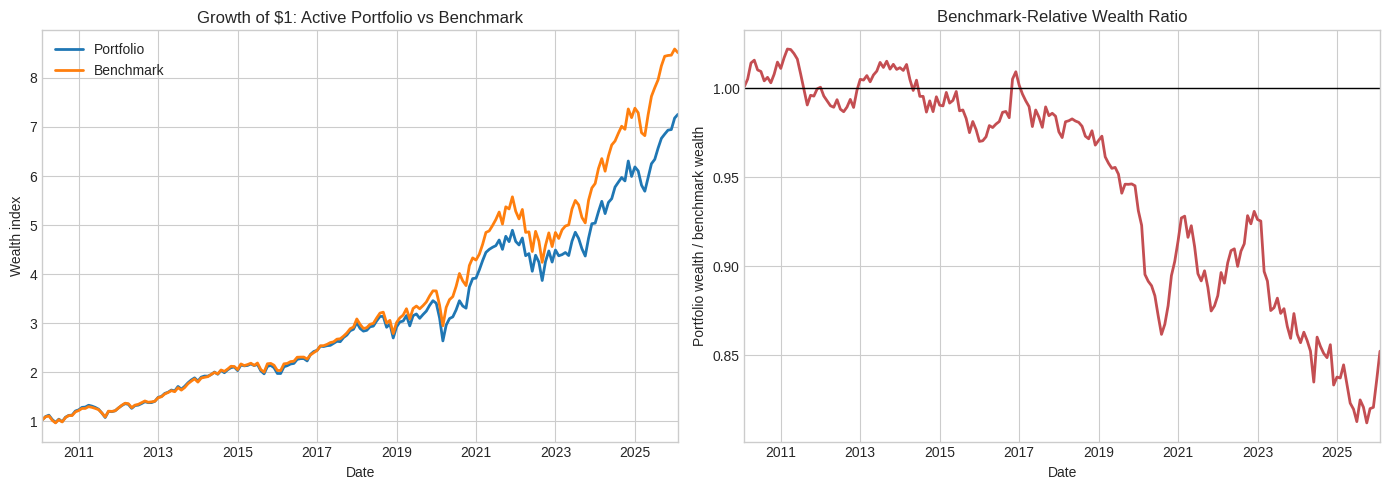

In [ ]:
# Plot total cumulative wealth and relative cumulative wealth side by side.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wealth.plot(ax=axes[0], linewidth=2)
axes[0].set_title("Growth of $1: Active Portfolio vs Benchmark")
axes[0].set_ylabel("Wealth index")

relative_wealth.plot(ax=axes[1], color="#C44E52", linewidth=2)
axes[1].axhline(1.0, color="black", linewidth=1)
axes[1].set_title("Benchmark-Relative Wealth Ratio")
axes[1].set_ylabel("Portfolio wealth / benchmark wealth")

plt.tight_layout()
plt.show()


### How To Read The Descriptive Plot

- Left panel: growth of `$1` for portfolio vs benchmark.
- Right panel: benchmark-relative wealth ratio versus the `1` line.
- Persistent drift in the right panel is the cumulative active result.


## FF3 Attribution

- Goal: split active return into a factor-related component and an alpha-like remainder.
- Use the same `FF3` factors (`RMRF`, `SMB`, `HML`) throughout the portfolio, benchmark, and active regressions.


### FF3 regression equations

We estimate the same FF3 model for the active portfolio, the benchmark, and the active return.

$$
R_{i,t}-R_{f,t}=\alpha_i+\beta_{i,MKT}\,\mathrm{RMRF}_t+\beta_{i,SMB}\,\mathrm{SMB}_t+\beta_{i,HML}\,\mathrm{HML}_t+\varepsilon_{i,t}
$$

for $i \in \{P,B\}$, and with active return
$$
AR_t = R_{P,t}-R_{B,t}
$$

the direct active regression is
$$
AR_t=\alpha_A+\beta_{A,MKT}\,\mathrm{RMRF}_t+\beta_{A,SMB}\,\mathrm{SMB}_t+\beta_{A,HML}\,\mathrm{HML}_t+\varepsilon_{A,t}.
$$

- $\alpha$ is the intercept (alpha-like unexplained component).
- $\beta$ coefficients measure exposure to the FF3 factors.


In [ ]:
# Estimate FF3 regressions for portfolio excess return, benchmark excess return, and active return.

def fit_ff3_regression(df, y_col):
    """Estimate a monthly OLS FF3 regression for one dependent variable."""
    sample = df[[y_col, *FF3_FACTORS]].dropna().copy()
    y = sample[y_col]
    X = sm.add_constant(sample[FF3_FACTORS])
    return sm.OLS(y, X).fit()


portfolio_ff3 = fit_ff3_regression(data, "portfolio_excess")
benchmark_ff3 = fit_ff3_regression(data, "benchmark_excess")
active_ff3 = fit_ff3_regression(data, "Active")

ff3_summary = pd.DataFrame(
    {
        "alpha (% per month)": [
            portfolio_ff3.params["const"] * 100,
            benchmark_ff3.params["const"] * 100,
            active_ff3.params["const"] * 100,
        ],
        "RMRF": [
            portfolio_ff3.params["RMRF"],
            benchmark_ff3.params["RMRF"],
            active_ff3.params["RMRF"],
        ],
        "SMB": [
            portfolio_ff3.params["SMB"],
            benchmark_ff3.params["SMB"],
            active_ff3.params["SMB"],
        ],
        "HML": [
            portfolio_ff3.params["HML"],
            benchmark_ff3.params["HML"],
            active_ff3.params["HML"],
        ],
        "R2": [
            portfolio_ff3.rsquared,
            benchmark_ff3.rsquared,
            active_ff3.rsquared,
        ],
        "nobs": [
            int(portfolio_ff3.nobs),
            int(benchmark_ff3.nobs),
            int(active_ff3.nobs),
        ],
    },
    index=[
        "Active portfolio excess return",
        "Benchmark excess return",
        "Active return",
    ],
).round(3)

print("FF3 regression summary")
display(ff3_summary)


FF3 regression summary


,alpha (% per month),RMRF,SMB,HML,R2,nobs
Active portfolio excess return,-0.0150,0.9520,0.0730,0.1820,0.9890,193
Benchmark excess return,0.0010,0.9830,-0.1360,0.0130,0.9960,193
Active return,-0.0160,-0.0320,0.2090,0.1690,0.7910,193


### How To Read The FF3 Regression Summary

- In the `Active return` row, `$R^2$` shows how much active variation `FF3` explains.
- `RMRF`, `SMB`, and `HML` signs/magnitudes describe benchmark-relative tilt direction and size.
- `alpha (% per month)` is the average active return not explained by FF3.


### Active tilts as loading differences

The active portfolio's FF3 exposures can be read as differences between portfolio and benchmark loadings.

$$
\Delta \beta_k = \beta_{P,k}-\beta_{B,k}, \qquad k \in \{\mathrm{RMRF},\mathrm{SMB},\mathrm{HML}\}
$$

and similarly for the intercept,
$$
\Delta \alpha = \alpha_P-\alpha_B.
$$

Under the same linear FF3 specification, the direct active regression should line up with these differences:
$$
\beta_{A,k} \approx \Delta \beta_k, \qquad \alpha_A \approx \Delta \alpha.
$$

- This table checks that the active regression is consistent with portfolio-minus-benchmark exposures.
- Any small mismatch is due to estimation/sample details.


In [ ]:
# Compare FF3 loadings for portfolio, benchmark, and active return.
portfolio_params = portfolio_ff3.params
benchmark_params = benchmark_ff3.params
active_params = active_ff3.params

exposure_compare = pd.DataFrame(
    {
        "Active portfolio": portfolio_params.reindex(["const", *FF3_FACTORS]),
        "Benchmark (SPY)": benchmark_params.reindex(["const", *FF3_FACTORS]),
        "Difference": (portfolio_params - benchmark_params).reindex(["const", *FF3_FACTORS]),
        "Direct active regression": active_params.reindex(["const", *FF3_FACTORS]),
    }
).rename(index={"const": "alpha"}).round(3)

print("FF3 loadings: portfolio, benchmark, and active tilt")
display(exposure_compare)


FF3 loadings: portfolio, benchmark, and active tilt


,Active portfolio,Benchmark (SPY),Difference,Direct active regression
alpha,-0.0000,0.0000,-0.0000,-0.0000
RMRF,0.9520,0.9830,-0.0320,-0.0320
SMB,0.0730,-0.1360,0.2090,0.2090
HML,0.1820,0.0130,0.1690,0.1690


### How To Read The Loading Comparison

- `Difference` is portfolio loading minus benchmark loading.
- `Direct active regression` should be close to `Difference`.
- Close match supports the benchmark-relative tilt identity.


### Mean active-return attribution

Average active return is decomposed into a factor-related piece plus an alpha-like remainder.

Starting from
$$
AR_t=\alpha_A+\sum_{k}\beta_{A,k}F_{k,t}+\varepsilon_{A,t},
$$

the mean decomposition is
$$
\overline{AR}\approx \alpha_A+\sum_k \beta_{A,k}\,\overline{F_k}.
$$

Define each factor's contribution as
$$
C_k=\beta_{A,k}\,\overline{F_k}.
$$

Then the explained mean active return is
$$
\widehat{\overline{AR}}=\alpha_A+\sum_k C_k.
$$

- $\beta_{A,k}$ is the active tilt from the FF3 active regression.
- $\overline{F_k}$ is the average realized payoff of factor $k$ over the sample.


In [ ]:
# Use the FF3 active regression to connect factor tilts to average factor payoffs.
factor_means = data[FF3_FACTORS].mean()
active_tilts = active_ff3.params[FF3_FACTORS]
factor_contributions = active_tilts * factor_means

# Each factor contribution is tilt times average realized factor payoff.
attribution_table = pd.DataFrame(
    {
        "Active tilt": active_tilts,
        "Average factor payoff (% per month)": factor_means * 100,
        "Contribution to average active return (% per month)": factor_contributions * 100,
    }
).round(3)

alpha_like = active_ff3.params["const"] * 100
factor_component_mean = attribution_table["Contribution to average active return (% per month)"].sum()
explained_mean_active_return = alpha_like + factor_component_mean
actual_mean_active_return = data["Active"].mean() * 100
residual_gap_bp = (actual_mean_active_return - explained_mean_active_return) * 100

display(attribution_table)

# Summarize explained and unexplained pieces of average active return.
attribution_summary = pd.DataFrame(
    {
        "Value": [
            alpha_like,
            factor_component_mean,
            explained_mean_active_return,
            actual_mean_active_return,
            residual_gap_bp,
        ]
    },
    index=[
        "Alpha-like unexplained component (% per month)",
        "Factor-related component (% per month)",
        "Explained mean active return (% per month)",
        "Actual mean active return (% per month)",
        "Difference (sample residual mean, bp)",
    ],
).round(3)

display(attribution_summary)


,Active tilt,Average factor payoff (% per month),Contribution to average active return (% per month)
RMRF,-0.0320,1.0950,-0.0350
SMB,0.2090,-0.0820,-0.0170
HML,0.1690,-0.0640,-0.0110


,Value
Alpha-like unexplained component (% per month),-0.0160
Factor-related component (% per month),-0.0630
Explained mean active return (% per month),-0.0790
Actual mean active return (% per month),-0.0780
"Difference (sample residual mean, bp)",0.0630


### How To Read The Attribution Table

- Contribution = active tilt x average factor payoff.
- Positive contribution helped active return; negative contribution hurt it.
- Compare explained and actual mean active return in the attribution summary.


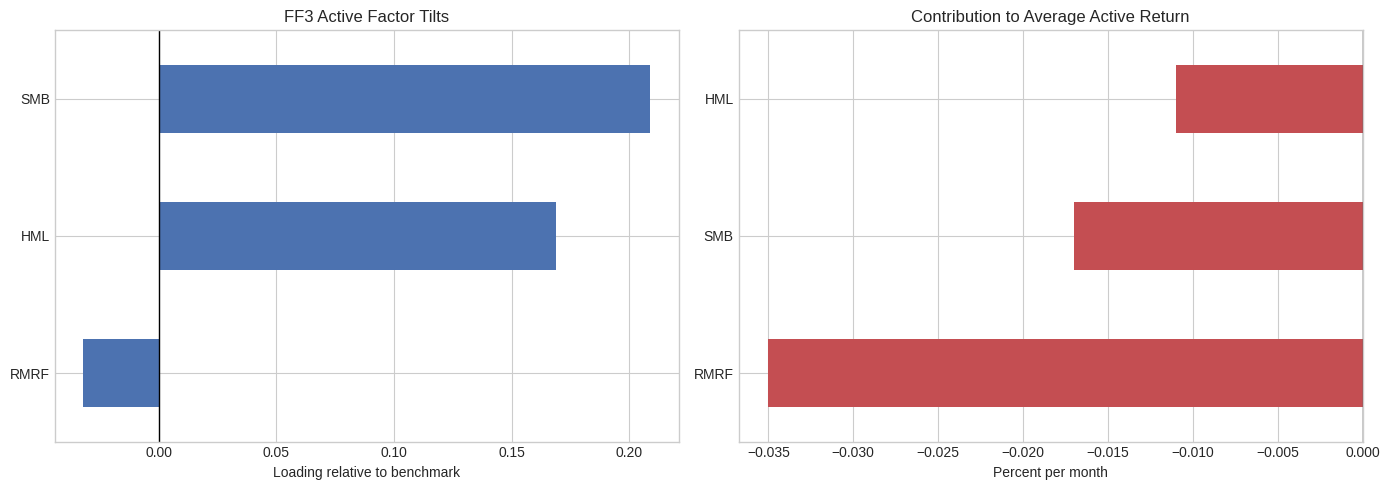

In [ ]:
# Plot active tilts and factor contributions.
plot_tilts = attribution_table["Active tilt"].sort_values()
plot_contrib = attribution_table["Contribution to average active return (% per month)"].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_tilts.plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("FF3 Active Factor Tilts")
axes[0].set_xlabel("Loading relative to benchmark")

plot_contrib.plot(kind="barh", ax=axes[1], color="#C44E52")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Contribution to Average Active Return")
axes[1].set_xlabel("Percent per month")

plt.tight_layout()
plt.show()


### How To Read The Attribution Charts

- Left chart: active tilts (exposures relative to `SPY`).
- Right chart: each factor's contribution to average active return.
- Bar sign indicates whether each factor helped or hurt benchmark-relative performance.


## FF3 Active-Risk Decomposition

- Use the same active `FF3` regression.
- Split active return into fitted factor component and residual.
- Decompose active variance into factor and residual shares.


### FF3 active-risk decomposition

Use the same active FF3 model to split active risk into a factor-related part and a residual part.

From
$$
AR_t=\alpha_A+\sum_k \beta_{A,k}F_{k,t}+\varepsilon_{A,t},
$$

define the factor-related component as
$$
FC_t=\sum_k \beta_{A,k}F_{k,t},
$$

and the residual component as
$$
u_t=\varepsilon_{A,t}=AR_t-\left(\alpha_A+FC_t\right).
$$

Tracking error is the volatility of active return:
$$
TE=\sigma(AR_t).
$$

Using the OLS decomposition, active variance is split as
$$
\mathrm{Var}(AR_t)\approx \mathrm{Var}(FC_t)+\mathrm{Var}(u_t).
$$

Variance shares are therefore
$$
\text{Factor share}=\frac{\mathrm{Var}(FC_t)}{\mathrm{Var}(AR_t)}, \qquad
\text{Residual share}=\frac{\mathrm{Var}(u_t)}{\mathrm{Var}(AR_t)}.
$$

- Variance adds cleanly; volatility does not.
- The intercept $\alpha_A$ affects mean active return, not active variance.


,Monthly std. dev. (% per month),Share of active variance (%)
Active return,0.8800,100.0000
Factor-related component,0.7800,79.0900
Residual component,0.4000,20.9100


In this OLS sample, factor-related and residual variances add to total active variance up to rounding. Variance, not volatility, adds cleanly.


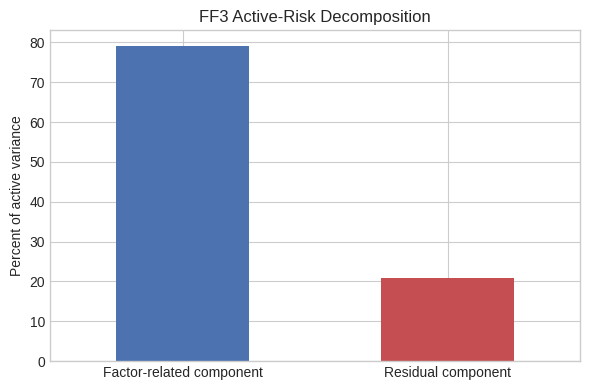

In [ ]:
# Build fitted factor and residual components from the FF3 active regression.
active_sample = data[["Active", *FF3_FACTORS]].dropna().copy()
active_sample["factor_component"] = active_sample[FF3_FACTORS].mul(active_tilts, axis=1).sum(axis=1)
active_sample["fitted_active_return"] = active_ff3.predict(sm.add_constant(active_sample[FF3_FACTORS]))
active_sample["residual"] = active_sample["Active"] - active_sample["fitted_active_return"]

# Compare total active variance with factor and residual pieces.
total_var = active_sample["Active"].var()
factor_var = active_sample["factor_component"].var()
residual_var = active_sample["residual"].var()

risk_table = pd.DataFrame(
    {
        "Monthly std. dev. (% per month)": [
            active_sample["Active"].std() * 100,
            active_sample["factor_component"].std() * 100,
            active_sample["residual"].std() * 100,
        ],
        "Share of active variance (%)": [
            100.0,
            factor_var / total_var * 100,
            residual_var / total_var * 100,
        ],
    },
    index=["Active return", "Factor-related component", "Residual component"],
).round(2)

display(risk_table)

print(
    "In this OLS sample, factor-related and residual variances add to total active variance up to rounding. Variance, not volatility, adds cleanly."
)

# Plot the two non-total pieces for visual comparison.
risk_table.loc[["Factor-related component", "Residual component"], "Share of active variance (%)"].plot(
    kind="bar",
    color=["#4C72B0", "#C44E52"],
    figsize=(6, 4),
)
plt.title("FF3 Active-Risk Decomposition")
plt.ylabel("Percent of active variance")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### How To Read The Active-Risk Output

- Table reports monthly volatility and share of active variance for each component.
- Variance shares, not volatility shares, show what drives tracking error.
- Higher factor share means active risk is mostly systematic.


## Takeaway

- One `FF3` framework carries the story from benchmark-relative return attribution to active risk.
